## Exploratory Data Analysis(EDA)
After collecting the data, perform an exploratory data analysis to uncover meaningful insights. This may include:
- Summary statistics of the dataset (counts, distributions, trends)
- Identification of common attributes (e.g., top product types, price ranges, frequent keywords
- Regional insights (e.g., location-based supplier patterns)
- Any anomalies, inconsistencies, or quality gaps in the scraped data to name a few

## 🔷 Workflow & Analysis Mapping
1. [Import python libraries](#section1)<br>
2. [Load Dataset](#section2)<br>
3. [Initial Data Inspection](#section3)<br>
4. [Check Missing Values](#section4)<br>
5. [Remove duplicate records](#section5)<br>
6. [Data Cleaning](#section6)<br>
7. [Data Preparation (Feature Engineering)](#section7)<br>
8. [Data Visualization](#section8)<br>
    - 8.1 Price distribution by products (histogram)
    - 8.2 Price range
    - 8.3 Price distribution by location
    - 8.4 Products by rating
    - 8.5 Supplier distribution by rating
    - 8.6 Supplier distribution by Location
    - 8.7 Frequent keyword analysis
    - 8.8 Correlation between features
9. [Insights and Hypotheses](#section9)<br>
    - Identify price trends
    - Regional patterns
    - Supplier behavior
    - Product Trends (Keywords)
    - Data Quality Observations

## 1. Import python libraries
<a id=section1> </a>


In [2]:
# import python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter


## 2. Load Dataset
<a id=section2> </a>

- Loaded JSON data into Pandas DataFrame
- Verified structure and previewed records

In [3]:
df = pd.read_json("../data/indiamart_data.json")
df.to_csv("../data/raw_data.csv", index=False)
df.head()

,product_name,price,supplier,address,rating
0,AUTOMATIC REELS PICK AND DROP MACHINE WITH BOX...,"₹ 12,00,000",Soham Industrial Machinery Limited,Surat,4.3
1,Customised Machines Equipment - Labh Group,"₹ 15,00,000",Labh Projects Private Limited ( Labh Group of ...,"Bodakdev, Ahmedabad",4.0
2,Single Station Bi Axial Machine,"₹ 12,50,000",Kuldevi Industries,"Odhav, Ahmedabad",4.1
3,Automatic Jerry Can Blow Molding Machine,"₹ 23,75,000",Blow Engineering,"Sakinaka, Mumbai",4.6
4,Ultrasonic Hot Fixing Machine,"₹ 30,000",J P Import & Export,Surat,4.3


## 3. Initial Data Inspection
<a id=section3> </a>

- Check structure
- Understand data types
- Basic overview

In [4]:
print("Total Records:", len(df))
print("Total Columns:", df.shape[1])
df.nunique()

Total Records: 28
Total Columns: 5


product_name    27
price           27
supplier        28
address         25
rating          10
dtype: int64

- The dataset contains 28 product records with key attributes such as product_name, price, supplier, address, and rating.
- There are multiple unique suppliers and address, indicating a diverse marketplace.

In [5]:
# records in each columns
df.count()

product_name    28
price           27
supplier        28
address         28
rating          28
dtype: int64

### Data Types

In [6]:
#data types
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_name  28 non-null     str    
 1   price         27 non-null     str    
 2   supplier      28 non-null     str    
 3   address       28 non-null     str    
 4   rating        28 non-null     float64
dtypes: float64(1), str(4)
memory usage: 3.5 KB


In [7]:
# Numerical/statistical Summary (Price & Rating)
df.describe()

,rating
count,28.000000
mean,4.282143
std,0.265349
min,3.500000
25%,4.100000
50%,4.300000
75%,4.400000
max,4.900000


## 4. Check Missing Values
<a id=section4> </a>

- Identified null values across dataset
- Understand missing data pattern

In [8]:
# checking and count null values
df.isnull().sum()

product_name    0
price           1
supplier        0
address         0
rating          0
dtype: int64

- Observed only one missing value in price column

## 5. Remove duplicate records
<a id=section5> </a>

- Check and remove duplicates
- Ensure data integrity

In [9]:
df.duplicated().sum()

np.int64(0)

- **No duplicate records found**

## 6. Data Cleaning
<a id=section6> </a>

- price is in string datatype need to convert into numeric
- Remove ₹ and commas from price
- Handle missing values

In [10]:
# convert str price to number
df['price'] = pd.to_numeric(
    df['price'].str.replace("₹", "").str.replace(",", ""),
    errors='coerce'
).astype('Int64')

df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_name  28 non-null     str    
 1   price         27 non-null     Int64  
 2   supplier      28 non-null     str    
 3   address       28 non-null     str    
 4   rating        28 non-null     float64
dtypes: Int64(1), float64(1), str(3)
memory usage: 3.3 KB


In [11]:
df.describe()

,price,rating
count,27.0,28.000000
mean,611691.37037,4.282143
std,727408.496995,0.265349
min,999.0,3.500000
25%,76000.0,4.100000
50%,275000.0,4.300000
75%,999999.5,4.400000
max,2525000.0,4.900000


- in price column there is single row conatin null, fill with average

In [12]:
df['price'] = df['price'].fillna(round(df['price'].mean()))
df.isnull().sum()

product_name    0
price           0
supplier        0
address         0
rating          0
dtype: int64

- now there is no null values in the dataset

## 7. Data Preparation (Feature Engineering)
<a id=section7> </a>

- Extract city from address column
- Add city as new feature 

In [13]:
df.head(2)

,product_name,price,supplier,address,rating
0,AUTOMATIC REELS PICK AND DROP MACHINE WITH BOX...,1200000,Soham Industrial Machinery Limited,Surat,4.3
1,Customised Machines Equipment - Labh Group,1500000,Labh Projects Private Limited ( Labh Group of ...,"Bodakdev, Ahmedabad",4.0


In [14]:
df['city'] = df['address'].apply(lambda x: x.split(",")[-1].strip())

In [15]:
df.head()

,product_name,price,supplier,address,rating,city
0,AUTOMATIC REELS PICK AND DROP MACHINE WITH BOX...,1200000,Soham Industrial Machinery Limited,Surat,4.3,Surat
1,Customised Machines Equipment - Labh Group,1500000,Labh Projects Private Limited ( Labh Group of ...,"Bodakdev, Ahmedabad",4.0,Ahmedabad
2,Single Station Bi Axial Machine,1250000,Kuldevi Industries,"Odhav, Ahmedabad",4.1,Ahmedabad
3,Automatic Jerry Can Blow Molding Machine,2375000,Blow Engineering,"Sakinaka, Mumbai",4.6,Mumbai
4,Ultrasonic Hot Fixing Machine,30000,J P Import & Export,Surat,4.3,Surat


- **clean column prodct_name in proper case**

In [16]:
df['product_name'] = df['product_name'].str.title()

In [42]:
df.head()

,product_name,price,supplier,address,rating,city,price_range
0,Automatic Reels Pick And Drop Machine With Box...,1200000,Soham Industrial Machinery Limited,Surat,4.3,Surat,High
1,Customised Machines Equipment - Labh Group,1500000,Labh Projects Private Limited ( Labh Group of ...,"Bodakdev, Ahmedabad",4.0,Ahmedabad,High
2,Single Station Bi Axial Machine,1250000,Kuldevi Industries,"Odhav, Ahmedabad",4.1,Ahmedabad,High
3,Automatic Jerry Can Blow Molding Machine,2375000,Blow Engineering,"Sakinaka, Mumbai",4.6,Mumbai,High
4,Ultrasonic Hot Fixing Machine,30000,J P Import & Export,Surat,4.3,Surat,Low


## 8. Data Visualization
<a id=section8> </a>

### 8.1. Price distribution by products (histogram)


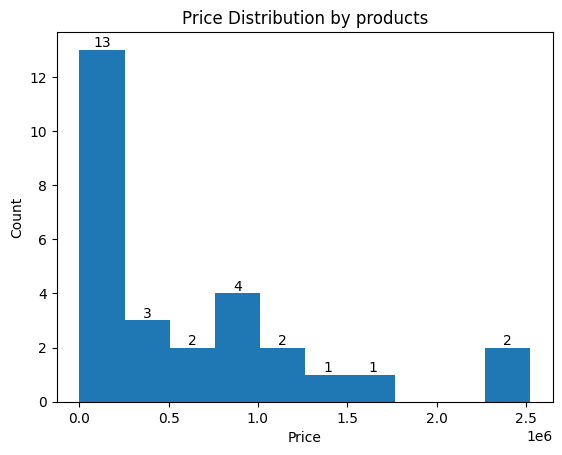

In [17]:
# Plot histogram
counts, bins, patches = plt.hist(df['price'], bins=10)

plt.grid(False) # Remove grid

# Add labels
plt.title("Price Distribution by products")
plt.xlabel("Price")
plt.ylabel("Count")

# Add data labels on bars
for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width()/2,
            count,
            int(count),
            ha='center',
            va='bottom'
        )

plt.show()

- The price distribution is right-skewed, with most products concentrated in the mid-price range
- A few products fall in the high-price range, indicating premium machinery
- The presence of higher-value outliers increases the overall average price

**i. Most expensive Product**

In [18]:
df.head(2)

,product_name,price,supplier,address,rating,city
0,Automatic Reels Pick And Drop Machine With Box...,1200000,Soham Industrial Machinery Limited,Surat,4.3,Surat
1,Customised Machines Equipment - Labh Group,1500000,Labh Projects Private Limited ( Labh Group of ...,"Bodakdev, Ahmedabad",4.0,Ahmedabad


In [19]:
max_row = df.loc[df['price'].idxmax()]

max_row[['product_name', 'price', 'supplier', 'address','rating']]

product_name    Automatic Block Moulding Thermocol Router Mach...
price                                                     2525000
supplier                                     Solar CNC Automation
address                                                  Vadodara
rating                                                        4.4
Name: 24, dtype: object

- The supplier **Solar CNC Automation**, located in **Vadodara**, offers one of the most expensive machines in the dataset — **Automatic Block Moulding Thermocol Router Machine** — with a rating of **4.4**, indicating high product value along with strong customer satisfaction.

**Top 5 Most expensive product with details**

In [20]:
df.sort_values(by='price',ascending=False)[
  ['product_name','price', 'supplier', 'address', 'rating']
].head(5)  

,product_name,price,supplier,address,rating
24,Automatic Block Moulding Thermocol Router Mach...,2525000,Solar CNC Automation,Vadodara,4.4
3,Automatic Jerry Can Blow Molding Machine,2375000,Blow Engineering,"Sakinaka, Mumbai",4.6
11,Aluminium Solar Panel Frame Dismantling Machin...,1550101,Rajesh Export & Import Co.,Hisar,4.7
1,Customised Machines Equipment - Labh Group,1500000,Labh Projects Private Limited ( Labh Group of ...,"Bodakdev, Ahmedabad",4.0
2,Single Station Bi Axial Machine,1250000,Kuldevi Industries,"Odhav, Ahmedabad",4.1


- Automatic and Solar machines are expensive

**ii. cheapest Product**

In [21]:
min_row = df.loc[df['price'].idxmin()]

min_row[['product_name', 'price', 'supplier', 'address','rating']]

product_name    Teresstic T Series, Packaging Size: 20 Ltr
price                                                  999
supplier                              Aero Global Services
address                                          New Delhi
rating                                                 4.0
Name: 19, dtype: object

- The supplier **Aero Global Services**, located in  **New Delhi**, offers one of the most cheaper machines in the dataset — Teresstic T Series, Packaging Size: 20 Ltr — with a rating of 4, indicating low product value along with average customer satisfaction.

In [22]:
df.sort_values(by='price',ascending=True)[
  ['product_name','price', 'supplier', 'address', 'rating']
].head(5) 

,product_name,price,supplier,address,rating
19,"Teresstic T Series, Packaging Size: 20 Ltr",999,Aero Global Services,New Delhi,4.0
9,Manual Standing Mop Making Machine,4500,AR Star Bazaar,"Chikhali, Pune",4.4
21,All Type Industrial Machinery,10000,Gajanand Engineering Works,Jodhpur,4.4
4,Ultrasonic Hot Fixing Machine,30000,J P Import & Export,Surat,4.3
6,Ultrasonic Hot Fixing Machine,30500,Matruchhaya Technology,Surat,4.9


- Packaging and making machines are cheaper in price

### 8.2 Price range 

In [23]:
df['price_range'] = pd.cut(df['price'], bins=5)

df['price_range'].value_counts()

price_range
(-1525.001, 505799.2]     16
(505799.2, 1010599.4]      6
(1010599.4, 1515399.6]     3
(2020199.8, 2525000.0]     2
(1515399.6, 2020199.8]     1
Name: count, dtype: int64

In [24]:
bins = [0, 50000, 200000, 500000, 1000000, df['price'].max()]
labels = ['Low', 'Lower-Mid', 'Mid', 'Upper-Mid', 'High']

df['price_range'] = pd.cut(df['price'], bins=bins, labels=labels)

df['price_range'].value_counts()

price_range
Lower-Mid    8
Upper-Mid    6
High         6
Low          5
Mid          3
Name: count, dtype: int64

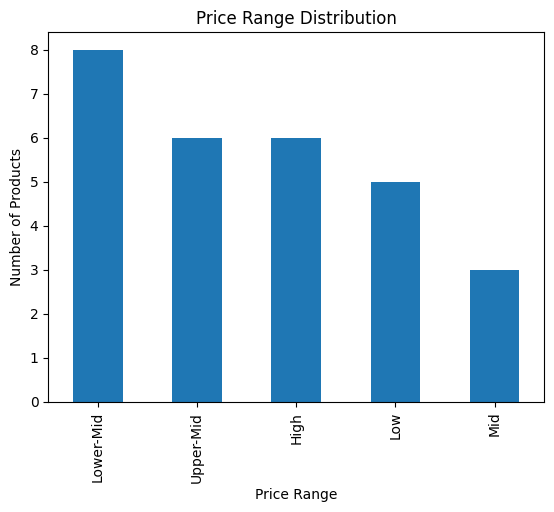

In [25]:
#custome price range distribution
df['price_range'].value_counts().plot(kind='bar')

import matplotlib.pyplot as plt
plt.title("Price Range Distribution")
plt.xlabel("Price Range")
plt.ylabel("Number of Products")
plt.show()

- Products are distributed across multiple price ranges from low to high
- Majority of products fall in the mid and upper-mid range, indicating moderate pricing
- A smaller number of products fall in the high-price category, representing premium industrial machines
- Low-price products indicate entry-level or basic machinery

### 8.3. Price distribution by location


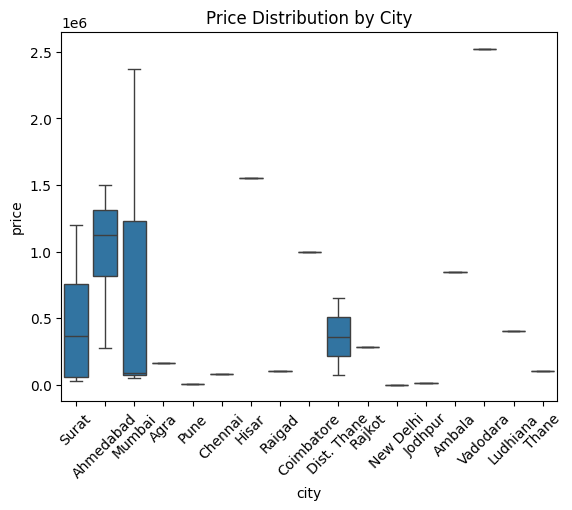

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.boxplot(x='city', y='price', data=df)

plt.xticks(rotation=45)
plt.title("Price Distribution by City")

plt.show()

Price distribution varies across cities, with industrial hubs showing wider price ranges and higher variability.

### 8.4 Products by rating


**Top 5 product list by rating**

In [27]:
df.sort_values(by='rating', ascending=False)[
    ['product_name','price', 'supplier', 'address', 'rating']
].head(5)

,product_name,price,supplier,address,rating
6,Ultrasonic Hot Fixing Machine,30500,Matruchhaya Technology,Surat,4.9
11,Aluminium Solar Panel Frame Dismantling Machin...,1550101,Rajesh Export & Import Co.,Hisar,4.7
3,Automatic Jerry Can Blow Molding Machine,2375000,Blow Engineering,"Sakinaka, Mumbai",4.6
5,"Mannual Brush Machine, Single Phase, 100 Dojon...",165000,BMT Tools,Agra,4.6
25,1 Shoe Lamination Machine,85000,Bio X,"Santacruz West, Mumbai",4.5


- Ultrasonic and Automatic machines are more likely for customer

### 8.5 Supplier distribution by rating


### Top 5 Supplier by Rating

In [28]:
df.head(2)

,product_name,price,supplier,address,rating,city,price_range
0,Automatic Reels Pick And Drop Machine With Box...,1200000,Soham Industrial Machinery Limited,Surat,4.3,Surat,High
1,Customised Machines Equipment - Labh Group,1500000,Labh Projects Private Limited ( Labh Group of ...,"Bodakdev, Ahmedabad",4.0,Ahmedabad,High


In [29]:
df.groupby('supplier')['rating'].mean().sort_values(ascending=False).head(5)

supplier
Matruchhaya Technology        4.9
Rajesh Export & Import Co.    4.7
Blow Engineering              4.6
BMT Tools                     4.6
Bio X                         4.5
Name: rating, dtype: float64

In [30]:
df.sort_values(by='rating', ascending=False)[
    ['supplier', 'rating','city']
].head(5)

,supplier,rating,city
6,Matruchhaya Technology,4.9,Surat
11,Rajesh Export & Import Co.,4.7,Hisar
3,Blow Engineering,4.6,Mumbai
5,BMT Tools,4.6,Agra
25,Bio X,4.5,Mumbai


Suppliers with consistently high ratings are likely to be more trusted in the market, making them key players in the industrial machinery segment.

### 8.6 Supplier distribution by location


In [31]:
df['city'].value_counts()

city
Surat          6
Ahmedabad      4
Mumbai         3
Dist. Thane    2
Agra           1
Pune           1
Chennai        1
Hisar          1
Raigad         1
Coimbatore     1
Rajkot         1
New Delhi      1
Jodhpur        1
Ambala         1
Vadodara       1
Ludhiana       1
Thane          1
Name: count, dtype: int64

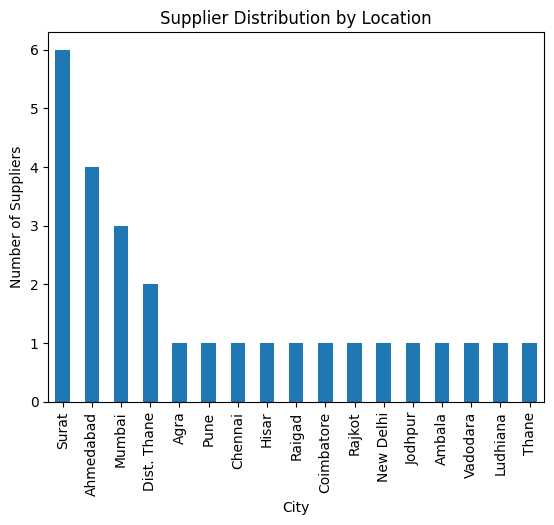

In [32]:
df['city'].value_counts().plot(kind='bar')

import matplotlib.pyplot as plt
plt.title("Supplier Distribution by Location")
plt.xlabel("City")
plt.ylabel("Number of Suppliers")
plt.show()

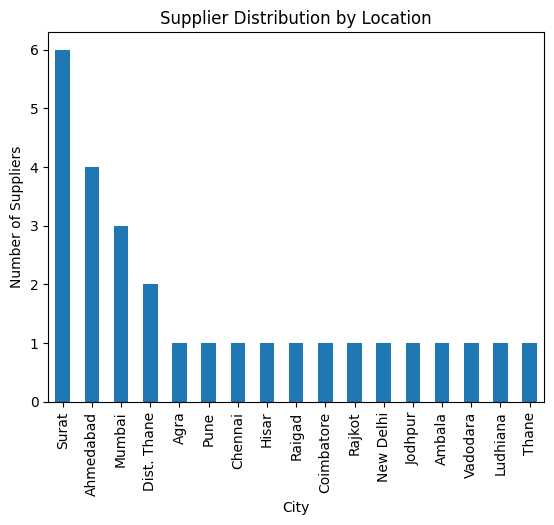

In [33]:
df['city'].value_counts().plot(kind='bar')

import matplotlib.pyplot as plt
plt.title("Supplier Distribution by Location")
plt.xlabel("City")
plt.ylabel("Number of Suppliers")
plt.show()

### 8.7 Frequent keyword analysis

In [34]:
from collections import Counter

# Combine all product names
text = " ".join(df['product_name'].dropna()).lower()

# Split into words
words = text.split()

# Count frequency
keyword_counts = Counter(words)

# Top 10 keywords
keyword_counts.most_common(10)

[('machine', 17),
 ('machine,', 6),
 ('automatic', 5),
 ('making', 5),
 ('ultrasonic', 3),
 ('hot', 3),
 ('fixing', 3),
 ('100', 3),
 ('capacity:', 3),
 ('single', 2)]

In [35]:
#Convert to DataFrame
keywords_df = pd.DataFrame(keyword_counts.most_common(10), columns=['keyword', 'count'])
keywords_df

,keyword,count
0,machine,17
1,"machine,",6
2,automatic,5
3,making,5
4,ultrasonic,3
5,hot,3
6,fixing,3
7,100,3
8,capacity:,3
9,single,2


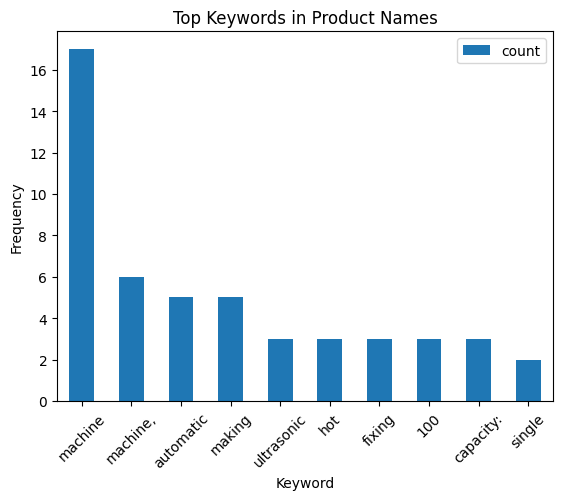

In [36]:
keywords_df.plot(kind='bar', x='keyword', y='count')

import matplotlib.pyplot as plt
plt.title("Top Keywords in Product Names")
plt.xlabel("Keyword")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

- The most common keywords include **machine**,**machine,**,**automatic**, **making**
- This indicates a strong focus on machine and automatic machine
- Frequent use of terms like **machine** & **automatic** suggests demand for efficient and modern machinery


### 8.6 Supplier distribution by Location

In [37]:
df['city'].value_counts()

city
Surat          6
Ahmedabad      4
Mumbai         3
Dist. Thane    2
Agra           1
Pune           1
Chennai        1
Hisar          1
Raigad         1
Coimbatore     1
Rajkot         1
New Delhi      1
Jodhpur        1
Ambala         1
Vadodara       1
Ludhiana       1
Thane          1
Name: count, dtype: int64

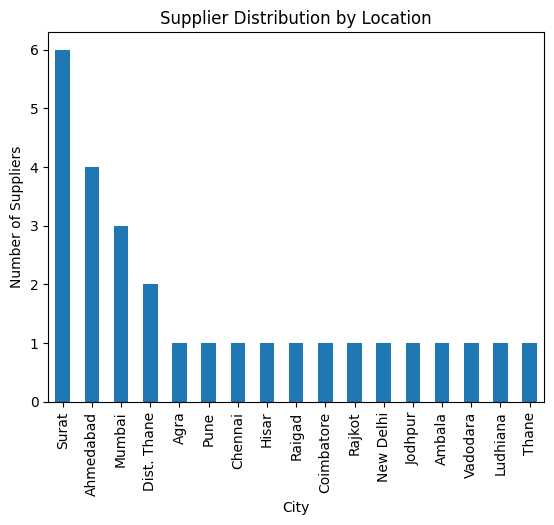

In [38]:
df['city'].value_counts().plot(kind='bar')

import matplotlib.pyplot as plt
plt.title("Supplier Distribution by Location")
plt.xlabel("City")
plt.ylabel("Number of Suppliers")
plt.show()

#### Location-Based Supplier Patterns
- Supplier distribution is concentrated in industrial cities such as **Surat**, **Ahmedabad** and **Mumbai**
- These cities act as major hubs for industrial machinery suppliers
- Some cities have a higher number of suppliers, indicating strong market presence and competition
- Most suppliers operate locally, with limited overlap across multiple cities

In [39]:
### 8.8 Correlatin between features

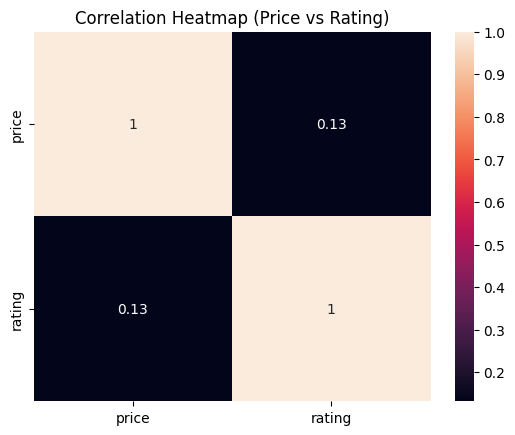

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[['price', 'rating']].corr()

plt.figure()
sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap (Price vs Rating)")
plt.show()

- The heatmap shows a weak relationship between price and rating, meaning price is not a strong factor in customer satisfaction.

## 9. Insights and Hypotheses
<a id=section9> </a>

- Identify price trends
- Regional patterns
- Supplier behavior
- Product Trends (Keywords)
- Data Quality Observations

### Identify price trends
**Insights:**
- Most products fall in the mid-to-high price range and few high-priced products indicate premium machinery segment
- Automatic and Solar machines are expensive
- Packaging and making machines are cheaper in price
- Price is not correlated with rating
- A few products have significantly higher prices, acting as outliers.
- Higher price does not always mean better rating

 **👉 Hypothesis:**
- Premium industrial machines are fewer but significantly influence average pricing.
- Customer satisfaction depends more on performance and reliability than price.

### Regional patterns
**Insights:**
- Supplier locations are concentrated in industrial cities like Mumbai, Surat, and Ahmadabad.
- These locations act as industrial hubs  
**👉 Hypothesis:**
- Industrial clusters lead to higher supplier density and competitive pricing.

### Supplier behavior
- Suppliers with consistently high ratings are likely to be more trusted in the market, making them key players in the industrial machinery segment.

**👉 Hypothesis:**
- Suppliers with consistently high ratings are more likely to gain customer trust and achieve higher visibility and demand in the industrial machinery market.

### Product Trends (Keywords)
**Insights:**

- The most common keywords include **machine**,**machine,**,**automatic**, **making**
- This indicates a strong focus on machine and automatic machine
- Frequent use of terms like **machine** & **automatic** suggests demand for efficient and modern machinery
**👉 Hypothesis:**
- Demand is shifting toward automated and high-efficiency machinery.

### Data Quality Observations
The dataset is clean and consistent, with only a single missing value observed in the price column. This minimal level of missing data indicates high data quality and reliability for analysis.

In [43]:
# save clean file
df.to_csv("../data/clean_data.csv", index=False)